# AP 155 Lab Exercise
---
## Exercise 4: Derivatives

_Instructions_: 
- **Report figure (See Problem 1):** Plot of mean absolute error vs. step size (spacing between points) when using the forward, backward, and central difference approach to get first derivative
- **Report discussion:** Explain the results of your figure. How do the central and non-central difference formulas arrive at such accuracies? Looking outward, when is each method of differentiation suitable/appropriate? 
  
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Hernando, Claire Marie M. 
- _Student No._: 2024-12904
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure

**Figure 1.**
![Scatter Plot of Three Derivative Approximations (Forward, Backward, Central) and the Analytically Derived Function (N = 257)](../Claire/Exercise%204.2/derivative_scatter.png)

**Figure 2.**
![Log-Log Scatter Plot of MAE vs. Grid Spacing (h)](../Claire/Exercise%204.2/mae_h_scatter.png)

### Report discussion

In the scatter plot of the three derivative approximations and the analytically derived function, it can be seen that Central Difference matches and aligns the curve of the analytically derived function, whereas the Forward and Backward Differences show visible phase shifts along steep gradients (rising curves). On the other hand, in the log-log error plot, Forward and Backward differences exhibit a linear slope of 1, confirming first-order convergence $\mathcal{O}(h)$. Meanwhile, the Central Difference follows a steeper slope of 2, confirming second-order convergence $\mathcal{O}(h^2)$. As viewed in the plot, smaller $h$ values lie toward the left side of the x-axis. As we move left, error initially drops down along a straight line. However, once $h < 10^{-5}$, we see scattered error points already and this is because round-off noise becomes larger than mathematical discretization error, causing the plotted error points to stop decreasing and bounce back upward. 

Looking outward, Central Difference is ideal for interior points on static spatial grids, boundary value problems (BVPs), and offline post-processing where symmetric neighboring points are known simultaneously. Forward Difference, on the other hand, is essential for explicit time-marching schemes, such as Forward Euler, that predict future states from current states. Lastly, the Backward Difference is known to be crucial for real-time causal signal processing (where future samples do not yet exist), implicit time-integration for stiff systems (Backward Euler), and right-domain boundaries where $x+h$ is out of bounds. 

### Other comments
At first, I had a hard time understanding what we are supposed to do, but after processing the problem, I have gotten its gist already. Also, my answers to the practical application and suitability were browsed from the internet. 


---
## Section 2: Code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

### Problem 1:

Consider the function:
$$ f(x) = 2 + 5x\sin\left(x + \frac{\pi}{4}\right)$$

Say you start with 257 points from 0 to $4\pi$ 

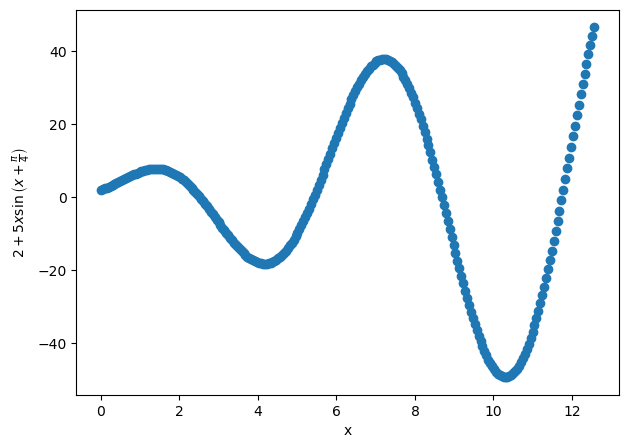

In [2]:
f_0 = lambda x: 2 + 5*x*np.sin(1*x+np.pi/4) # This is the original function
x = np.linspace(0, 4*np.pi, 257)
fig, ax = plt.subplots(figsize = (7,5))
ax.scatter(x, f_0(x))
ax.set_ylabel(r"$2 + 5x\sin\left(x + \frac{\pi}{4}\right)$")
ax.set_xlabel("x")
fig.show()
fig.savefig('f_x.png')

- Create a function that gets the first derivative approximation using the forward, backward, and central difference formulas. (Bonus, not required): Make the function flexible to non-evenly spaced data
- To give yourself a visualization, plot (in a single axis):
  - the three derivative approximations
  - the analytically derived function

- Get the mean absolute error of each of the approximations compared to the analytically derived function
- Repeat the above step for increasing number of points (decreasing spacing) - instead of 256 points, take 512/1024/128/64 points, etc.

- (For the report) Make a plot of the mean absolute error vs the spacing between points. In this plot, there should be three curves: One for the forward, one for the backward, and one for the central difference approximation

In [3]:
#Calling the functions clearly

# Original Function
def f(x):
    return 2 + 5 * x * np.sin(x + np.pi/4)

def df_analytical(x):
    return 5 * np.sin(x + np.pi/4) + 5 * x * np.cos(x + np.pi/4)

def get_derivatives(x, y): 
    """Computes for the numerical derivative (forward, backward, and central difference) of a function f at point x. 
    This is flexible to non-evenly spaced data.
    """
    dx = np.diff(x)
    dy = np.diff(y)

    # Forward Difference
    df_fwd = dy / dx

    #Backward Difference
    df_bwd = dy / dx

    #Central Difference
    h_back, h_fore = dx[:-1], dx[1:]
    y_prev, y_curr, y_next = y[:-2], y[1:-1], y[2:]

    num = (
        (h_back**2) * y_next
        - (h_fore**2) * y_prev
        + (h_fore**2 - h_back**2) * y_curr
    )
    den = h_fore * h_back * (h_fore + h_back)
    df_cnt = num / den 

    return df_fwd, df_bwd, df_cnt

In [4]:
# Setting up grid when N = 257
N = 257
x = np.linspace(0, 4 * np.pi, N)
y = f(x)
df_exact = df_analytical(x)

fwd, bwd, cnt = get_derivatives(x, y)

# Computing Mean Absolute Error 
mae_fwd = np.mean(np.abs(fwd - df_exact[:-1]))
mae_bwd = np.mean(np.abs(bwd - df_exact[1:]))
mae_cnt = np.mean(np.abs(cnt - df_exact[1:-1]))

print(f"MAE Forward Difference:  {mae_fwd:.6e}")
print(f"MAE Backward Difference: {mae_bwd:.6e}")
print(f"MAE Central Difference:  {mae_cnt:.6e}")

MAE Forward Difference:  4.995543e-01
MAE Backward Difference: 5.005318e-01
MAE Central Difference:  9.652198e-03


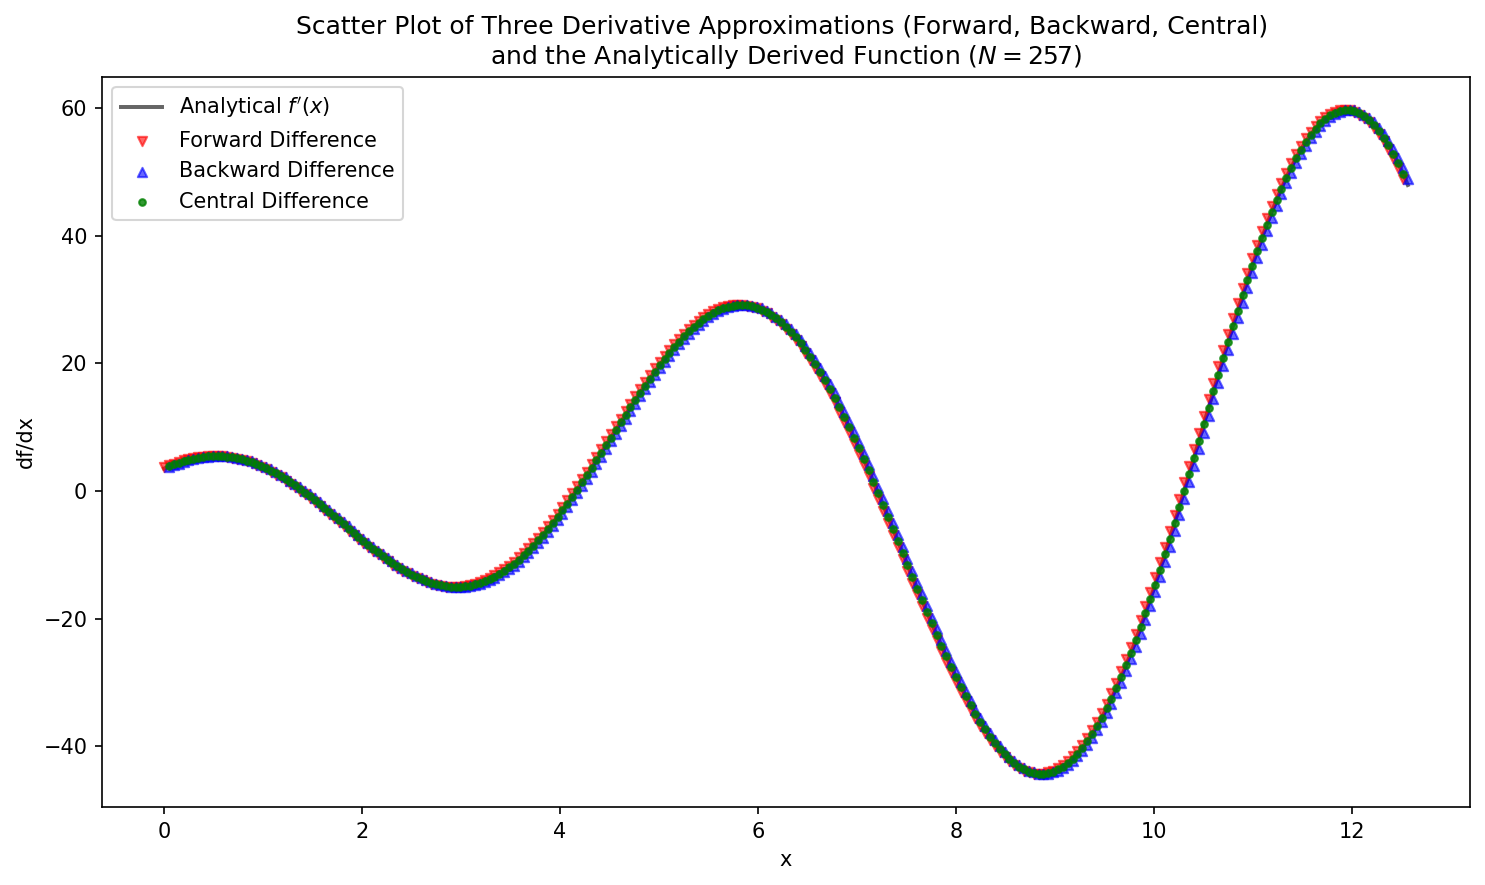

In [5]:
# Plotting the scatter plot
plt.figure(figsize=(10, 6), dpi=150)

plt.plot(
    x,
    df_exact,
    'k-',
    label="Analytical $f'(x)$",
    linewidth=1.9,
    alpha=0.6,
    zorder=1,
)
plt.scatter(
    x[:-1],
    fwd,
    color='red',
    s=20,
    marker='v',
    label='Forward Difference',
    alpha=0.6,
    zorder=2,
)
plt.scatter(
    x[1:],
    bwd,
    color='blue',
    s=20,
    marker='^',
    label='Backward Difference',
    alpha=0.6,
    zorder=2,
)
plt.scatter(
    x[1:-1],
    cnt,
    color='green',
    s=10,
    label='Central Difference',
    alpha=0.8,
    zorder=3,
)

plt.xlabel('x')
plt.ylabel('df/dx')
plt.title('Scatter Plot of Three Derivative Approximations (Forward, Backward, Central) \nand the Analytically Derived Function ($N = 257$)')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig("derivative_scatter.png")
plt.show()

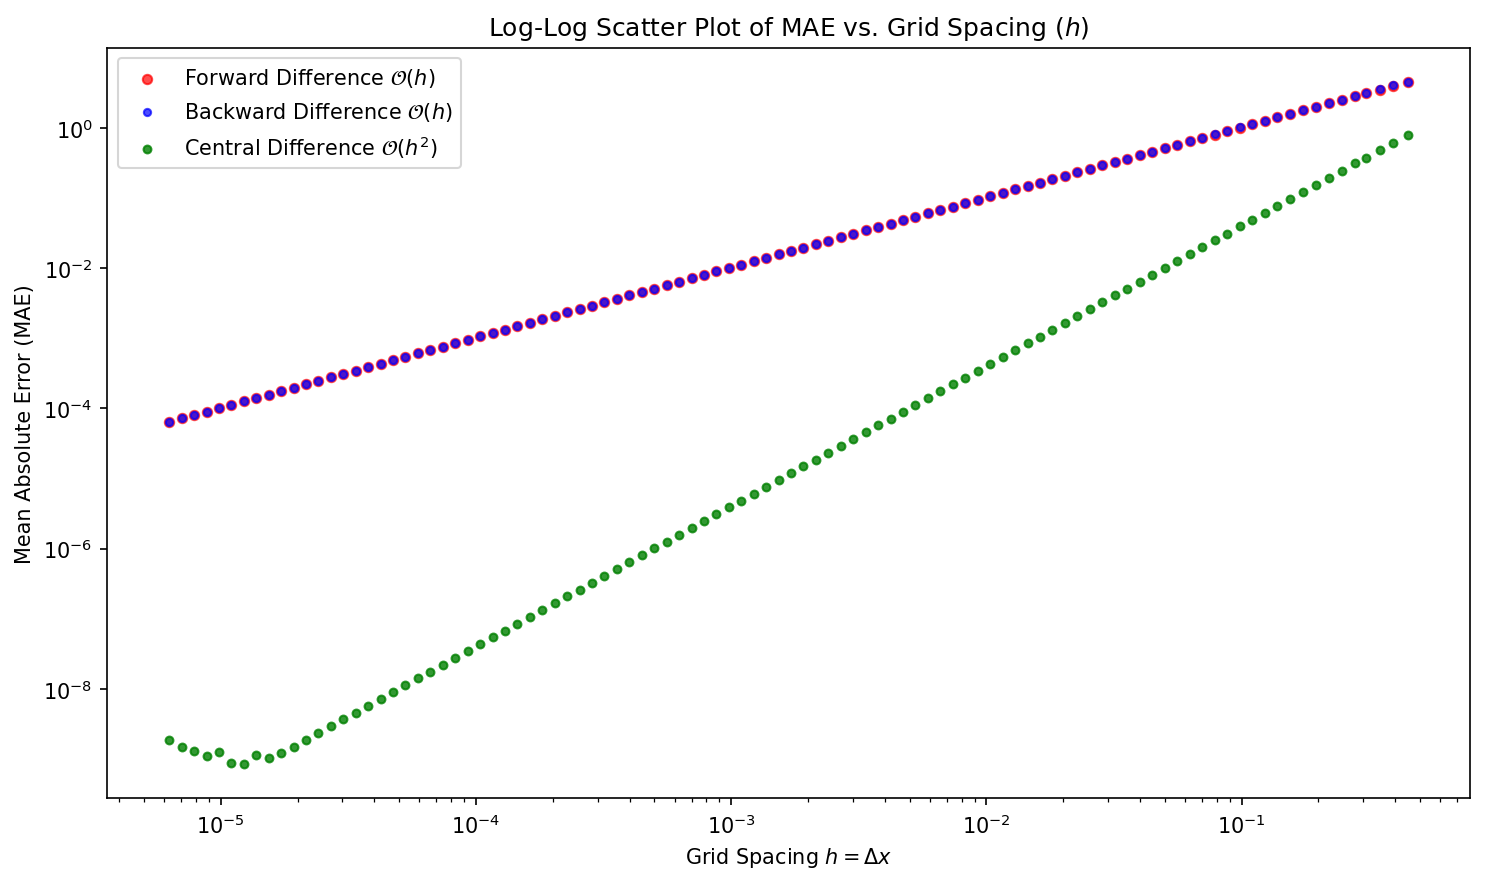

In [6]:
# Computing Mean Absolute Error (MAE) across grid sizes
point_counts = np.unique(
    np.logspace(np.log10(30), np.log10(2e6), num=100).astype(int)
) # This is generating 100 logarithmic point counts from N = 30 to N = 2,000,000, thereby including 64/128/256/512/1024 points.
spacings, maes_fw, maes_bw, maes_cd = [], [], [], []

for n_pts in point_counts: # Iterating through every grid size 
  x_i = np.linspace(0, 4 * np.pi, n_pts)
  y_i = f(x_i)
  df_ex_i = df_analytical(x_i)

  h_i = x_i[1] - x_i[0] # Updates spacing for each resolution, wherein  as the number of points increase, the space decreases.
  fw_i, bw_i, cd_i = get_derivatives(x_i, y_i)

  spacings.append(h_i) # Storing MAE for all three finite different methods at every value of $h$. 
  maes_fw.append(np.mean(np.abs(fw_i - df_ex_i[:-1])))
  maes_bw.append(np.mean(np.abs(bw_i - df_ex_i[1:])))
  maes_cd.append(np.mean(np.abs(cd_i - df_ex_i[1:-1])))  

# Plotting the Log-log Scatter Plot for Error vs. Spacing ($h$)
plt.figure(figsize=(10, 6), dpi=150)

# Setting-up scatter markers
plt.scatter(
    spacings,
    maes_fw,
    color='red',
    s=20,
    alpha=0.7,
    label=r'Forward Difference $\mathcal{O}(h)$',
)

plt.scatter(
    spacings,
    maes_bw,
    color='blue',
    s=12,
    alpha=0.7,
    marker='o',
    label=r'Backward Difference $\mathcal{O}(h)$',
)

plt.scatter(
    spacings,
    maes_cd,
    color='green',
    s=14,
    alpha=0.8,
    marker='o',
    label=r'Central Difference $\mathcal{O}(h^2)$',
)

# Apply logarithmic axes
plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'Grid Spacing $h = \Delta x$')
plt.ylabel('Mean Absolute Error (MAE)')
plt.title('Log-Log Scatter Plot of MAE vs. Grid Spacing ($h$)')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig("mae_h_scatter.png")
plt.show()

#### Problem 1 code summary

This script evaluates the accuracy of forward, backward, and central finite difference schemes against the analytical derivative of $f(x) = 2 + 5x \sin\left(x + \frac{\pi}{4}\right)$ across spatial grid resolutions scaling up to $N = 2,000,000$. Specifically, this uses vectorization via slicing to allow fast numerical evaluation even when processing millions of data points, non-uniform stencil formulation using $h_{\text{fore}}$ and $h_{\text{back}}$ to ensure that the central difference calculation remains generalizable for non-evenly spaced data, logarithmic point sweep to capture a bigger picture of the plot, 

---

## Section 3 (Notes)

### Non-central difference formulas (First Derivative)

* Forward 
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{x})}{h} + O(h)
$$

* Backward
$$
f'(x_i) = \frac{f(x_{i}) - f(x_{i-1})}{h} + O(h)
$$



### Central-difference formulas

* First Derivative
$$
f'(x_i) = \frac{f(x_{i+1}) - f(x_{i-1})}{2h} + O(h^2)
$$

* Second Derivative
$$
f''(x_i) = \frac{f(x_{i+1}) - 2f(x_{i}) + f(x_{i-1})}{h^2} + O(h^2)
$$

Note: to avoid confusion, think: $x_i$ is `x[i]`, and $h$ is the gap between `x[i+1]` and `x[i]`.


In [7]:
## Useful tips. Not required to solve the problems below!

# Suppose you have a Numpy array
x = np.linspace(1, 10, 10)
print(x)

# I can move all values to the left/right using roll
x_roll = np.roll(x, 1) # change 1 to -1, what happens? 
x_roll2 = np.roll(x, -1)
print(x_roll)

# then I could exploit array operations to get their difference
x_diff = (x_roll - x)[1:]
print(x_diff)
# Be careful with the boundaries!

x_diff2 = (x_roll2 - x_roll)[:]
print(x_diff2)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[10.  1.  2.  3.  4.  5.  6.  7.  8.  9.]
[-1. -1. -1. -1. -1. -1. -1. -1. -1.]
[-8.  2.  2.  2.  2.  2.  2.  2.  2. -8.]
